<div style="background-color:#d5f5e3; padding:20px; border-left:8px solid #27AE60; border-radius:8px; color:#1b1b1b;">

## **1er Proyecto de Regresión Lineal**

**Autora:** Anais Aponte  
**Bootcamp:** 4Geeks Academy – Intro to Machine Learning  
**Proyecto:** Medical Insurance Cost Prediction  

</div>

<div style="background-color:#d6eaff; border-left:6px solid #4a90e2; padding:15px; border-radius:8px; color:#1b1b1b;">

### 📝 **Instrucciones**

#### **Predecir el coste del seguro médico de una persona**


La importante compañía de seguros 4Geeks Insurance S.L. quiere calcular, en función de los datos fisiológicos de sus clientes, cuál va a ser la prima (coste) que debe asumir cada uno de ellos. Para ello, ha reunido a un equipo completo de médicos y en función de datos de otras compañías y un estudio particular han logrado reunir un conjunto de datos para entrenar un modelo predictivo.

</div>

<div style="background-color:#d6eaff; border-left:6px solid #4a90e2; padding:15px; border-radius:8px; color:#1b1b1b;">

### 📝 **Paso 1: Carga del conjunto de datos**

El dataset utilizado en este proyecto es **medical_insurance_cost.csv**.

Para facilitar la reproducibilidad y evitar dependencias externas, el archivo ha sido previamente descargado y almacenado dentro del repositorio en la siguiente ruta:

📁 `data/raw/medical_insurance_cost.csv`

De esta forma, el notebook puede ejecutarse directamente sin necesidad de acceder a enlaces externos.

A continuación se realizan primero las importaciones necesarias y, posteriormente, la carga del dataset para iniciar el análisis.

</div>

In [1]:
# IMPORTACIONES

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.linear_model import Ridge, Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
# Cargamos el fichero con los datos a analizar desde la carpeta raw del repositorio
# Usamos ruta relativa para asegurar portabilidad del notebook
df = pd.read_csv('../data/raw/medical_insurance_cost.csv')

# Visualizamos una muestra aleatoria de 10 registros para tener una primera impresión del dataset
# y evitar sesgarnos por un posible orden previo de las filas (ya que algunos datasets pueden estar ordenados (por fecha, id, etc.)
df.sample(10)

,age,sex,bmi,children,smoker,region,charges
1198,40,male,29.355,1,no,northwest,6393.60345
1048,25,female,22.515,1,no,northwest,3594.17085
798,58,female,33.100,0,no,southwest,11848.14100
610,47,female,29.370,1,no,southeast,8547.69130
9,60,female,25.840,0,no,northwest,28923.13692
36,62,female,32.965,3,no,northwest,15612.19335
261,20,female,26.840,1,yes,southeast,17085.26760
1006,28,male,29.260,2,no,northeast,4438.26340
199,64,female,39.330,0,no,northeast,14901.51670
438,52,female,46.750,5,no,southeast,12592.53450


<div style="background-color: #fff3cd; border-left: 6px solid #ffecb5; padding: 15px; border-radius: 5px">

### 💡 **Observación**

El dataset contiene información sobre los distintos clientes de la aseguradora. Incluye variables sobre su:
* **fisiologia**: edad (age), sexo(sex), IMC(bmi), nro de hijos(children) y si es fumador o no(smoker). Y otra variable sobre su 
* **region** y finalmente 
* **costo/prima (charges)** de la poliza de seguro para cada cliente.

</div>

<div style="background-color: #fff3cd; border-left: 6px solid #ffecb5; padding: 15px; border-radius: 5px">

A continuación se detallan las variables incluidas en el dataset:


| Variable  | Descripción |
|----------|------------|
| age      | Edad del beneficiario principal |
| sex      | Género del beneficiario |
| bmi      | Índice de masa corporal |
| children | Número de dependientes cubiertos por el seguro |
| smoker   | Indica si la persona es fumadora |
| region   | Región de residencia en EE.UU |
| charges  | Coste del seguro médico |

Este diccionario de datos será clave para interpretar correctamente las relaciones entre variables durante el análisis exploratorio (EDA).

</div>

<div style="background-color:#d6eaff; border-left:6px solid #4a90e2; padding:15px; border-radius:8px; color:#1b1b1b;">

### **Paso 2: Realiza un EDA completo**

</div>

<div style="background-color:#d6eaff; border-left:6px solid #4a90e2; padding:15px; border-radius:8px; color:#1b1b1b;">

### **Paso 2.1: Inspección inicial del dataset**

</div>

In [3]:
# Estructura del dataset
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


In [4]:
# Dimensiones
df.shape

(1338, 7)

In [5]:
# Valores nulos
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

<div style="background-color: #fff3cd; border-left: 6px solid #ffecb5; padding: 15px; border-radius: 5px">

### 💡 **Observacion**

A partir de la inspección inicial del dataset, se obtiene el siguiente resumen de las variables:

| Variable | Descripción | Tipo de dato | Valores nulos |
|----------|------------|-------------|---------------|
| age      | Edad del beneficiario principal | int64   | 0 |
| sex      | Género del beneficiario        | object  | 0 |
| bmi      | Índice de masa corporal       | float64 | 0 |
| children | Número de dependientes cubiertos por el seguro | int64   | 0 |
| smoker   | Indica si la persona es fumadora | object  | 0 |
| region   | Región de residencia en EE.UU | object  | 0 |
| charges  | Coste del seguro médico      | float64 | 0 |

El dataset contiene un total de **1.338 observaciones** y **7 variables**.

No se detectan valores nulos en ninguna de las variables, por lo que no es necesario realizar ningún tratamiento adicional en esta fase.

</div>

<div style="background-color:#d6eaff; border-left:6px solid #4a90e2; padding:15px; border-radius:8px; color:#1b1b1b;">

### **Paso 2.2: Inspección valores unicos y duplicados**

</div>

In [6]:
df_uniques = df.nunique()
df_repeated = len(df) - df_uniques

resumen = pd.DataFrame({
    'valores_unicos': df_uniques,
    'valores_repetidos': df_repeated
})

resumen

,valores_unicos,valores_repetidos
age,47,1291
sex,2,1336
bmi,548,790
children,6,1332
smoker,2,1336
region,4,1334
charges,1337,1


<div style="background-color: #fff3cd; border-left: 6px solid #ffecb5; padding: 15px; border-radius: 5px">

### **💡 Observación**

El análisis de valores únicos y repetidos muestra que ninguna de las variables del dataset actúa como identificador único de los registros, ya que todas presentan valores repetidos en mayor o menor medida.

Se observan posibles variables categóricas como `sex`, `smoker` y `region` ya que tienen un número reducido de valores únicos. Por otro lado, variables como `bmi` y `charges` presentan una mayor variedad de valores, aunque siguen existiendo repeticiones.

Destaca especialmente la variable `charges`, que presenta prácticamente todos sus valores únicos, lo que indica una alta variabilidad en el coste del seguro, mientras que el resto de variables muestran patrones de repetición esperables según su naturaleza.

</div>

In [7]:
# Contar el número de registros duplicados en el dataset
df.duplicated().sum()

np.int64(1)

<div style="background-color: #fff3cd; border-left: 6px solid #ffecb5; padding: 15px; border-radius: 5px">

### 💡 **Observación**

Hay una fila que es idéntica a otra en TODAS las columnas, veamoslas

</div>

In [8]:
# Mostrar todas las filas duplicadas (original y copia) para su inspección
df[df.duplicated(keep=False)]

,age,sex,bmi,children,smoker,region,charges
195,19,male,30.59,0,no,northwest,1639.5631
581,19,male,30.59,0,no,northwest,1639.5631


<div style="background-color: #fff3cd; border-left: 6px solid #ffecb5; padding: 15px; border-radius: 5px">

### 💡 **Observación**

Se detecta la existencia de registros duplicados en el dataset. 

Al analizar las filas duplicadas, se observa que coinciden exactamente en todas las variables, lo que sugiere que se trata de una duplicación del mismo registro.

Si bien no se dispone de un identificador único que permita asegurar que no se trata de dos individuos distintos con las mismas características, dado el contexto de dataset limpio y académico, se descarta esta posibilidad.

Por tanto, se procede a eliminar los duplicados para evitar posibles sesgos en el modelo.
</div>

In [9]:
# Eliminar los registros duplicados para evitar sesgos en el análisis
df = df.drop_duplicates()

In [10]:
# Se corrobora que ya no hay filas duplicadas
df[df.duplicated(keep=False)]

,age,sex,bmi,children,smoker,region,charges


<div style="background-color:#d6eaff; border-left:6px solid #4a90e2; padding:15px; border-radius:8px; color:#1b1b1b;">

### **Paso 2.3: Análisis estadístico descriptivo**

</div>

In [11]:
# Se calculan estadísticas descriptivo para las variables numericas comprender su distribución, rango de valores y posibles valores outliers
df.describe()

,age,bmi,children,charges
count,1337.000000,1337.000000,1337.000000,1337.000000
mean,39.222139,30.663452,1.095737,13279.121487
std,14.044333,6.100468,1.205571,12110.359656
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.290000,0.000000,4746.344000
50%,39.000000,30.400000,1.000000,9386.161300
75%,51.000000,34.700000,2.000000,16657.717450
max,64.000000,53.130000,5.000000,63770.428010


<div style="background-color: #fff3cd; border-left: 6px solid #ffecb5; padding: 15px; border-radius: 5px">

### 💡 **Observación: Análisis de dispersión y posibles outliers**

Al comparar el valor medio (mean) con la desviación estándar (std), se puede evaluar qué tan dispersos están los datos en cada variable.

- En variables como **age** y **bmi**, la distancia entre la media y la desviación estándar es moderada, lo que indica cierta variabilidad pero dentro de rangos razonables.
- En **children**, la desviación es muy baja, lo que sugiere que los valores están bastante concentrados y no hay grandes extremos.
- Sin embargo, en **charges**, la desviación estándar es muy alta en comparación con la media, lo que indica una gran dispersión de los datos.

Este comportamiento sugiere la presencia de valores extremos (outliers) en la variable **charges**.

Además, al observar los valores máximos:
- El máximo de **charges** (~63,770) está muy alejado de la media (~13,270), reforzando la idea de que existen valores atípicos que están influyendo fuertemente en la distribución.

👉 En conclusión, **charges es la variable con mayor presencia de outliers**, lo cual puede afectar el rendimiento del modelo y debería tenerse en cuenta en fases posteriores.

🔍 Para confirmar visualmente esta hipótesis y analizar con mayor detalle la distribución de las variables, a continuación se realiza un análisis univariable mediante histogramas y boxplots.

</div>

<div style="background-color:#d6eaff; border-left:6px solid #4a90e2; padding:15px; border-radius:8px; color:#1b1b1b;">

### **Paso 2.3: Análisis univariable de variables numéricas**

</div>

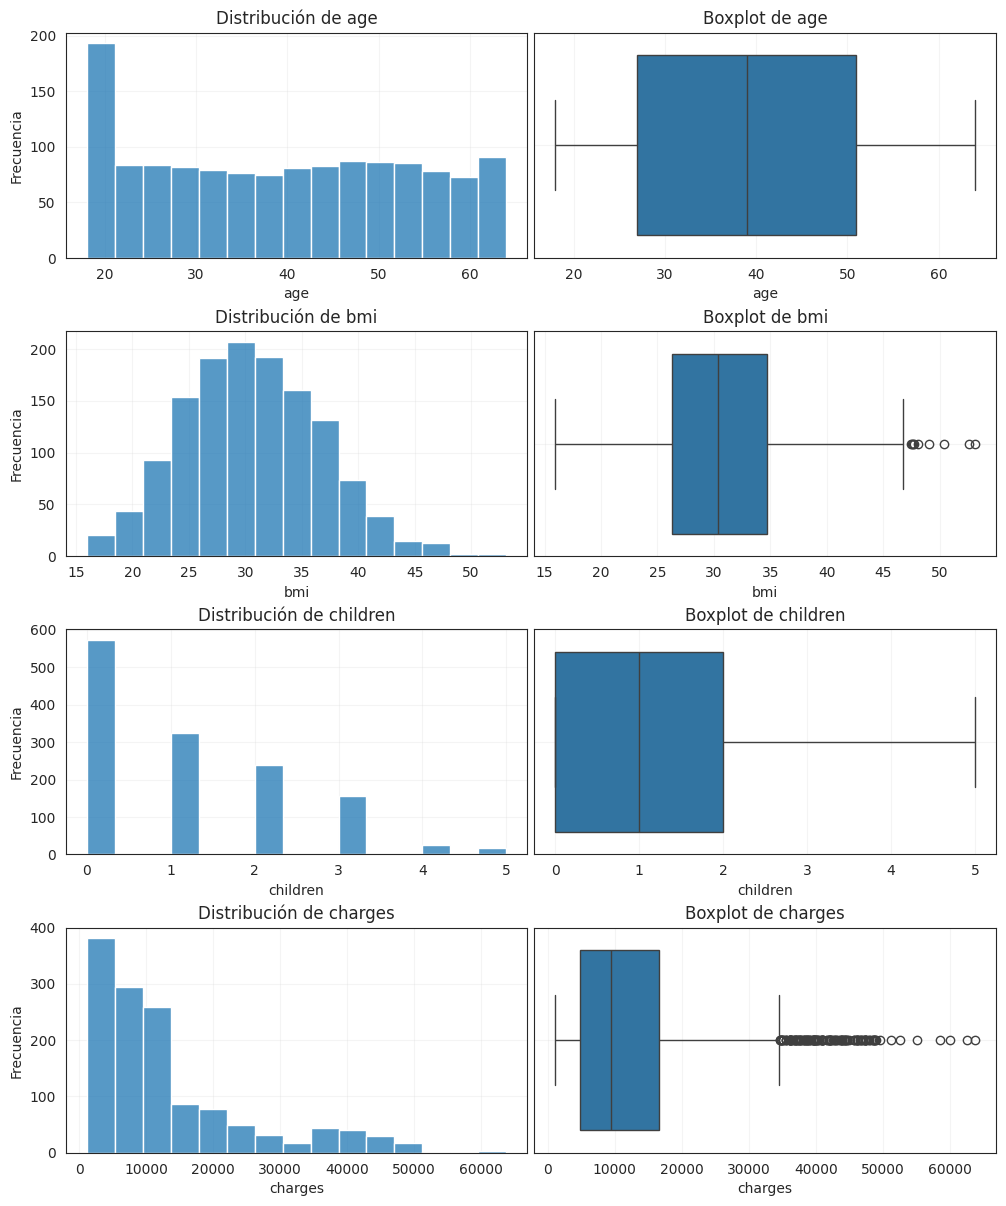

In [12]:
# Se seleccionan automáticamente las variables numéricas
num_vars = df.select_dtypes(include=['int64', 'float64']).columns

# Definimos un estilo limpio sin rejilla para personalizarla manualmente después
sns.set_style("white")

# Se ajusta el tamaño de la figura para que cada fila ocupe menos alto y el notebook requiera menos scroll
fig, axes = plt.subplots(len(num_vars), 2, figsize=(10, 3*len(num_vars)))

for i, col in enumerate(num_vars):

    # Histograma
    sns.histplot(df[col], bins=15, ax=axes[i,0])
    axes[i,0].set_title(f"Distribución de {col}")
    axes[i,0].set_xlabel(col)
    axes[i,0].set_ylabel("Frecuencia")
    axes[i,0].grid(True, alpha=0.2)  # grid suave

    # Boxplot
    sns.boxplot(x=df[col], ax=axes[i,1])
    axes[i,1].set_title(f"Boxplot de {col}")
    axes[i,1].set_xlabel(col)
    axes[i,1].grid(True, alpha=0.2)  # grid suave

# Ajustamos el espaciado entre gráficos para aprovechar mejor el espacio
plt.tight_layout(pad=0.5)
plt.show()

<div style="background-color: #fff3cd; border-left: 6px solid #ffecb5; padding: 15px; border-radius: 5px">

### 💡 **Observaciones de los gráficos**

Tal y como se sospechaba en el análisis estadístico descriptivo, los histogramas y boxplots permiten confirmar varias ideas sobre la distribución de las variables numéricas:

- **age**: las edades presentan una distribución bastante uniforme entre los 18 y los 64 años. No se observan valores extremos en esta variable, aunque sí una mayor concentración de observaciones en edades bajas.

- **bmi**: la mayor parte de los valores se concentran alrededor de 30, por lo que la distribución tiene una forma aproximadamente acampanada. Sin embargo, el boxplot confirma la presencia de algunos valores altos que podrían considerarse outliers.

- **children**: la mayoría de las personas no tienen hijos o tienen pocos. La distribución está muy concentrada en valores bajos, especialmente en 0, y no se observan extremos especialmente preocupantes.

- **charges**: como ya sugerían la media, la desviación estándar y la distancia entre el valor máximo y la media, esta es la variable con mayor dispersión. El histograma muestra una distribución claramente sesgada a la derecha, mientras que el boxplot confirma la presencia de numerosos valores atípicos altos.

👉 En conclusión, el análisis visual confirma lo observado en el análisis descriptivo: **charges es la variable más problemática en términos de dispersión y outliers**, por lo que será importante tenerlo en cuenta en fases posteriores del modelado.

</div>

<div style="background-color:#d6eaff; border-left:6px solid #4a90e2; padding:15px; border-radius:8px; color:#1b1b1b;">

### **Paso 2.4: Análisis univariable de variables categóricas**

</div>

In [13]:
# Se seleccionan las posibles variables categóricas
cat_vars = df.select_dtypes(include=['object', 'string']).columns

# Creamos un resumen más legible de las variables categóricas
cat_summary = pd.DataFrame({
    "variable": cat_vars,
    "n_valores_unicos": [df[col].nunique() for col in cat_vars],
    "valores": [", ".join(map(str, df[col].dropna().unique())) for col in cat_vars]
})

cat_summary

,variable,n_valores_unicos,valores
0,sex,2,"female, male"
1,smoker,2,"yes, no"
2,region,4,"southwest, southeast, northwest, northeast"


<div style="background-color: #fff3cd; border-left: 6px solid #ffecb5; padding: 15px; border-radius: 5px">

### 💡 **Observación**

Las variables categóricas se identifican combinando el tipo de dato, el número de valores únicos y su significado.

En este dataset:
- `sex`, `smoker` y `region` son categóricas, ya que representan grupos definidos y tienen pocos valores únicos.
- Esta clasificación se confirma tanto por su tipo (`object`) como por el número limitado de categorías.

**NOTA:** Aunque la variable `children` es de tipo numérico (`int`), presenta valores discretos (0, 1, 2, 3, 4, 5), por lo que podría considerarse como una variable categórica ordinal.
Sin embargo, en este análisis se decide mantenerla como variable numérica, ya que:
- Representa una cantidad (número de hijos)
- Tiene un orden natural
- Puede aportar información útil en el modelo como variable continua


👉 A continuación, se analizará la distribución de estas variables mediante gráficos.

</div>

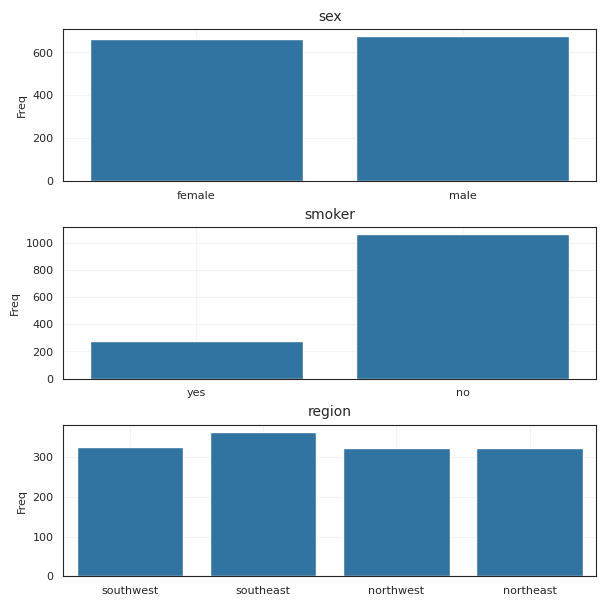

In [14]:
# countplot de las variables categóricas

# Definimos un estilo limpio sin rejilla para personalizarla manualmente después
sns.set_style("white")

fig, axes = plt.subplots(len(cat_vars), 1, figsize=(6, 6))  # más compacto

# Si solo hay una variable, axes no es lista → lo convertimos
if len(cat_vars) == 1:
    axes = [axes]

for i, col in enumerate(cat_vars):
    sns.countplot(x=col, data=df, ax=axes[i])
    
    axes[i].set_title(f"{col}", fontsize=10)
    axes[i].set_xlabel("")
    axes[i].set_ylabel("Freq", fontsize=8)
    axes[i].tick_params(axis='x', labelsize=8)
    axes[i].tick_params(axis='y', labelsize=8)
    axes[i].grid(True, alpha=0.2)

# Ajustamos automáticamente los espacios entre gráficos para evitar solapamientos
plt.tight_layout(pad=0.5)
plt.show()

<div style="background-color: #fff3cd; border-left: 6px solid #ffecb5; padding: 15px; border-radius: 5px">

### 💡 **Observación: Variables categóricas**

A partir de los gráficos de frecuencias se observa lo siguiente:

- **sex**: la distribución está bastante equilibrada entre hombres y mujeres, por lo que no parece haber sesgo en esta variable.
- **smoker**: existe un claro desbalance, con una mayoría de personas no fumadoras. Esto podría influir significativamente en el modelo, ya que es una variable que ya vimos que tiene mucho impacto en el coste.
- **region**: las observaciones están bastante repartidas entre las distintas regiones, sin grandes desequilibrios.

👉 En general, no se observan inconsistencias en las variables categóricas, aunque el desbalance en `smoker` será importante tenerlo en cuenta en el modelado.

</div>

<div style="background-color:#d6eaff; border-left:6px solid #4a90e2; padding:15px; border-radius:8px; color:#1b1b1b;">

### **Paso 2.5: variables (numericas & categoricas) vs charges**

Objetivo: Entender qué variables afectan al coste del seguro (charges)
* ¿cómo cambian los charges según variables numéricas?
* ¿hay diferencias de charges entre grupos?

</div>

<div style="background-color:#d6eaff; border-left:6px solid #4a90e2; padding:15px; border-radius:8px; color:#1b1b1b;">

##### **Paso 2.5.1 Variables numéricas vs charges**

Se comienza graficando (scatterplot): Se usa este grafico porque es el estándar para analizar la relación entre dos variables numéricas.

</div>

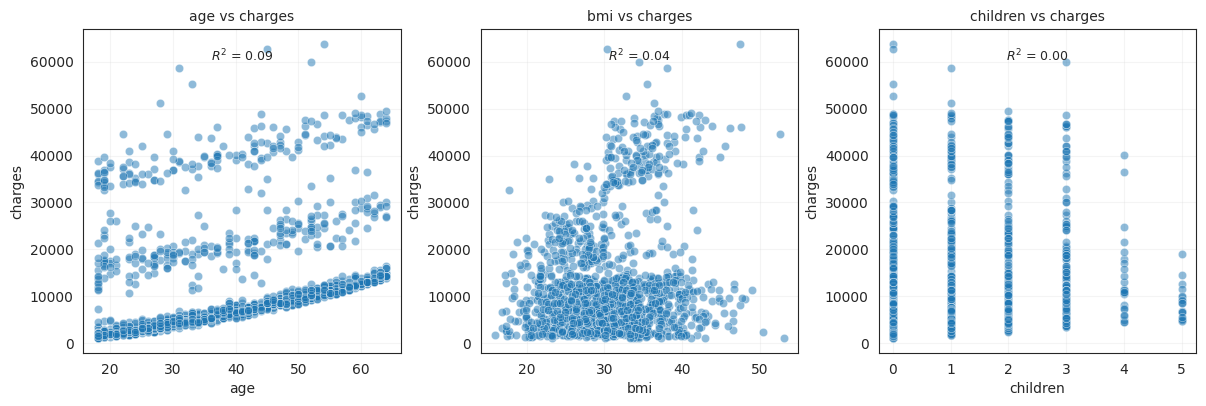

In [15]:
# Scatterplots: variables numéricas vs charges + R² (versión compacta en grid)

num_vars = df.select_dtypes(include=['int64', 'float64']).columns

# Se excluye la variable objetivo
num_vars = num_vars.drop('charges')

n_cols = 3  # número de columnas
n_rows = (len(num_vars) + n_cols - 1) // n_cols  # cálculo dinámico de filas

fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 4*n_rows))

axes = axes.flatten()  # aplanamos para iterar fácilmente

for i, col in enumerate(num_vars):
    
    # Scatter
    sns.scatterplot(x=df[col], y=df['charges'], ax=axes[i], alpha=0.5)
    
    # Cálculo de R²
    r = np.corrcoef(df[col], df['charges'])[0, 1]
    r2 = r**2
    
    # Mostrar R²
    axes[i].text(0.5, 0.9, f"$R^2$ = {r2:.2f}",
                 transform=axes[i].transAxes,
                 ha='center',
                 fontsize=9)
    
    axes[i].set_title(f"{col} vs charges", fontsize=10)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("charges")
    
    axes[i].grid(True, alpha=0.2)

# Eliminar ejes vacíos si hay
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout(pad=0.5)
plt.show()

<div style="background-color: #fff3cd; border-left: 6px solid #ffecb5; padding: 15px; border-radius: 5px">

### 💡 **Observación: Relación entre variables numéricas y charges**

A partir de los scatterplots se observa que no existe una relación lineal clara entre la variable objetivo `charges` y las variables numéricas (`age`, `bmi`, `children`).

- En **age**, se aprecia una ligera tendencia creciente, pero con mucha dispersión. El valor de \(R^2\) (~0.09) indica que la variable explica muy poco la variabilidad de `charges`.
- En **bmi**, aunque parece haber cierta relación en algunos rangos, la dispersión es alta y el \(R^2\) (~0.04) confirma que su capacidad explicativa es baja.
- En **children**, no se observa ninguna relación aparente con `charges` (\(R^2 \approx 0\)), lo que sugiere que esta variable no tiene influencia significativa de forma individual.

👉 En conclusión, **las variables numéricas por sí solas no explican bien el coste del seguro**, por lo que será necesario analizar otras variables (especialmente categóricas) o combinaciones entre variables para mejorar el modelo.

</div>

<div style="background-color:#d6eaff; border-left:6px solid #4a90e2; padding:15px; border-radius:8px; color:#1b1b1b;">

##### **Paso 2.5.2 Variables categóricas vs charges**

Se utilizan **boxplots** para analizar la relación entre variables categóricas y la variable objetivo `charges`.  
Este gráfico permite comparar la **distribución de una variable numérica entre diferentes categorías**, mostrando la mediana, la dispersión y posibles valores extremos.

</div>

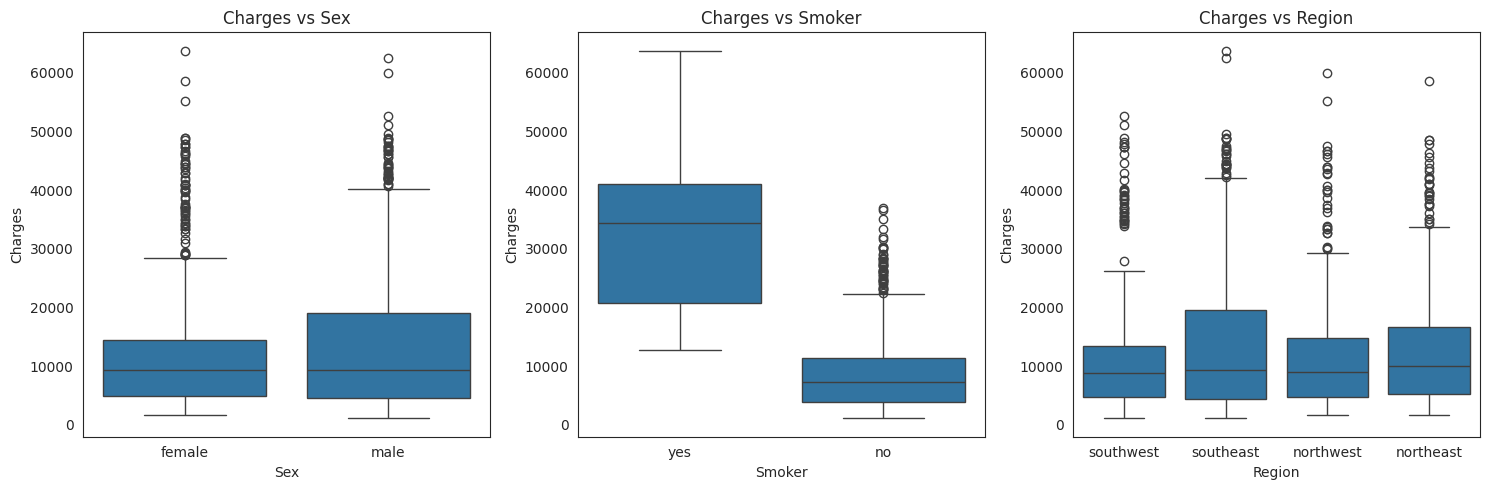

In [16]:
# Definimos las variables categóricas que queremos analizar frente a la variable objetivo (charges)
categorical_cols = ['sex', 'smoker', 'region']

# Creamos una figura con 3 subplots en una sola fila (uno por cada variable categórica)
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Recorremos cada variable categórica para generar su boxplot correspondiente
for i, col in enumerate(categorical_cols):
    
    # Boxplot: permite comparar la distribución de 'charges' entre las distintas categorías
    sns.boxplot(x=col, y='charges', data=df, ax=axes[i])
    axes[i].set_title(f'Charges vs {col.capitalize()}')
    axes[i].set_xlabel(col.capitalize())
    axes[i].set_ylabel('Charges')

# Ajustamos los espacios entre gráficos para que no se solapen
plt.tight_layout()

# Mostramos la figura final
plt.show()

<div style="background-color: #fff3cd; border-left: 6px solid #ffecb5; padding: 15px; border-radius: 5px">

### 💡 **Observación: Relación entre variables categóricas y charges**

A partir de los boxplots se pueden identificar diferencias en la distribución de `charges` según las variables categóricas:

- En **sex**, no se observan diferencias relevantes entre hombres y mujeres. Las medianas y la dispersión son muy similares, por lo que esta variable no parece tener un impacto significativo en el coste del seguro.
  
- En **smoker**, se observa una diferencia muy clara: las personas fumadoras presentan valores de `charges` significativamente más altos que las no fumadoras. La mediana es mucho mayor y la dispersión también, lo que indica que esta variable tiene un fuerte impacto en el coste del seguro.
  
- En **region**, no se aprecian diferencias marcadas entre regiones. Aunque hay cierta variabilidad, las distribuciones son bastante similares, por lo que su influencia parece limitada.

👉 En conclusión, **la variable `smoker` destaca como la más influyente sobre `charges`**, mientras que `sex` y `region` no muestran un impacto significativo de forma individual.

👉 Sin embargo, este análisis es univariable. Para entender mejor cómo influye `smoker` en combinación con variables numéricas (como `age` o `bmi`), se analizará su efecto en gráficos bivariables.

</div>

<div style="background-color:#d6eaff; border-left:6px solid #4a90e2; padding:15px; border-radius:8px; color:#1b1b1b;">

#### **Paso 2.5.3: Graficos Bivariables**

**Objetivo:** Analizar cómo se relaciona la variable objetivo (`charges`) con otras variables del dataset, incorporando una tercera dimensión (como `smoker`) para entender mejor los patrones observados.


</div>

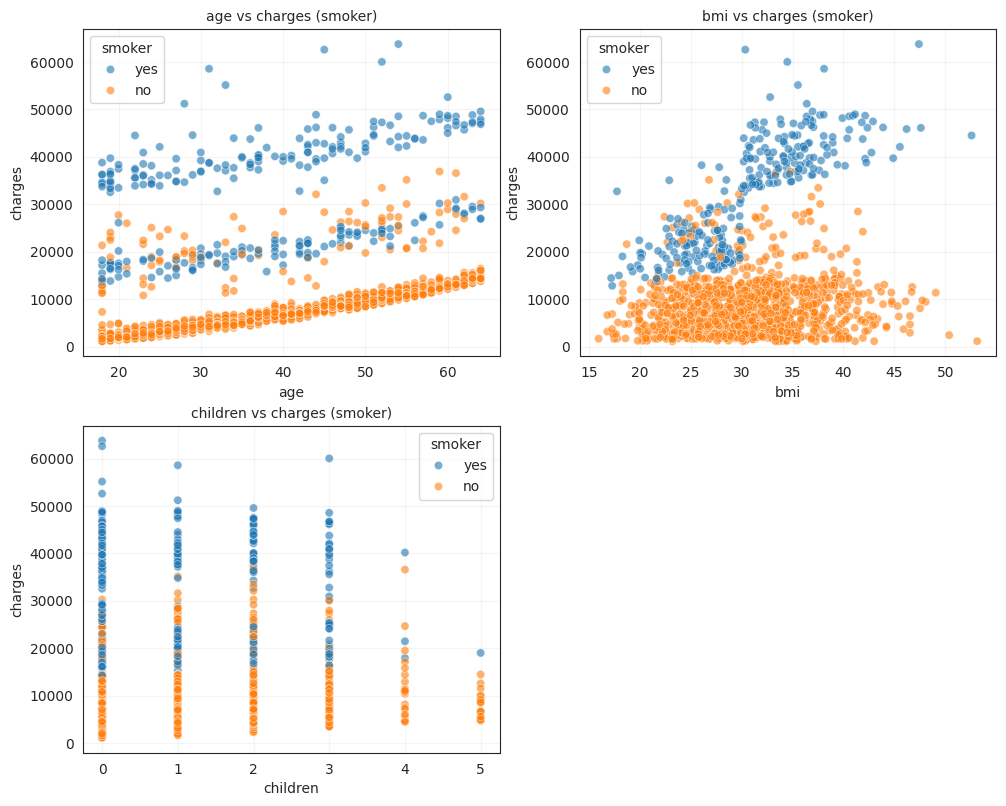

In [17]:
# Scatterplots: variables numéricas vs charges diferenciando por smoker

num_vars = df.select_dtypes(include=['int64', 'float64']).columns
num_vars = num_vars.drop('charges')  # excluimos la variable objetivo

n_cols = 2
n_rows = (len(num_vars) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(10, 4*n_rows))
axes = axes.flatten()

for i, col in enumerate(num_vars):
    
    # Scatter con color según si es fumador o no
    sns.scatterplot(
        x=df[col],
        y=df['charges'],
        hue=df['smoker'],
        ax=axes[i],
        alpha=0.6
    )
    
    axes[i].set_title(f"{col} vs charges (smoker)", fontsize=10)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("charges")
    
    axes[i].grid(True, alpha=0.2)

# Eliminamos ejes vacíos si sobran
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout(pad=0.5)
plt.show()

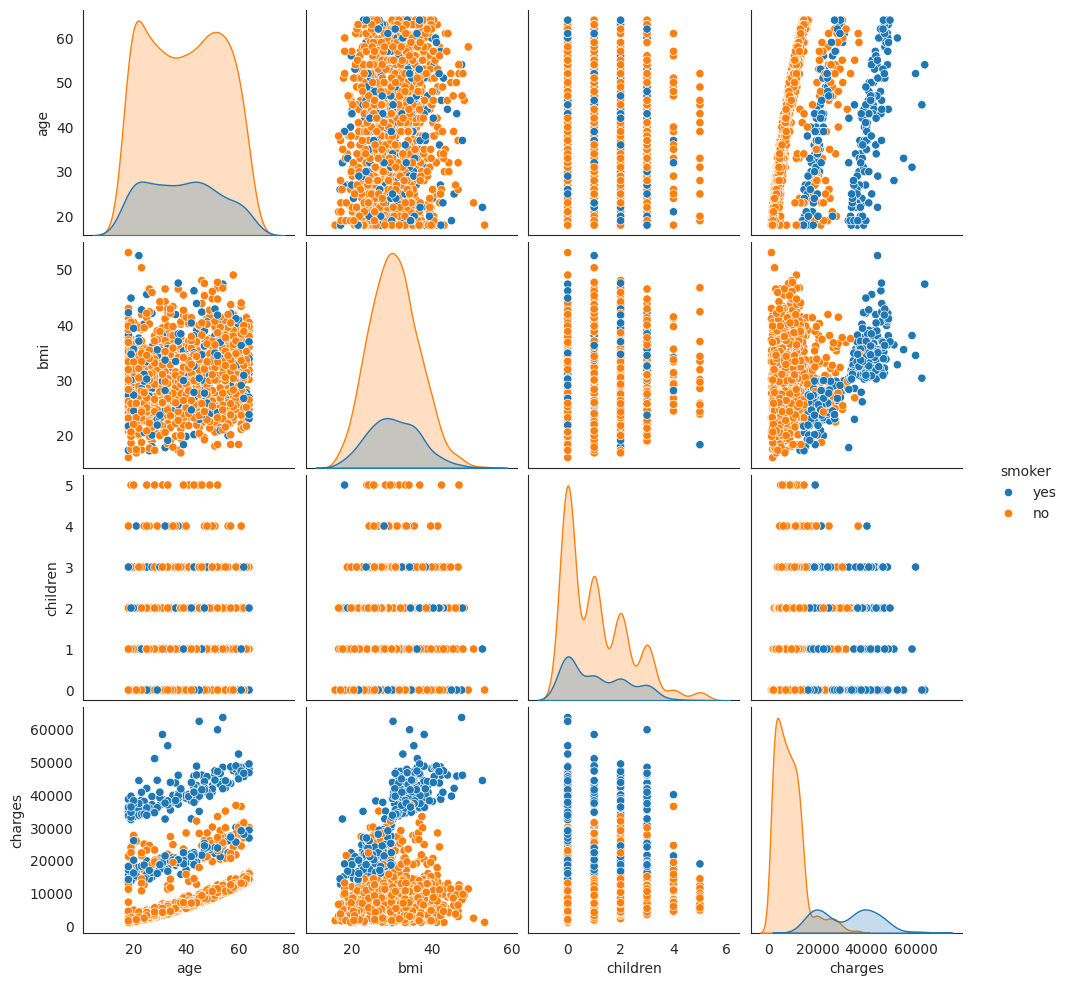

In [18]:
sns.pairplot(df, hue='smoker')
plt.show()

<div style="background-color: #fff3cd; border-left: 6px solid #ffecb5; padding: 15px; border-radius: 5px">

### 💡 **Observación: Impacto de la variable smoker en la relación con charges**

Al analizar las variables numéricas diferenciando por la variable `smoker`, se observa un patrón muy claro:

- Los datos se separan en **dos grupos bien definidos**: fumadores y no fumadores.
- Para prácticamente cualquier valor de **age**, **bmi** o **children**, los fumadores presentan valores de `charges` significativamente más altos.
- En el caso de **bmi**, además, se aprecia que en fumadores existe una relación más marcada: a mayor BMI, mayores costes.
- En cambio, en no fumadores, los costes se mantienen en rangos mucho más bajos y con menor dispersión.

👉 Este comportamiento sugiere que la variable `smoker` **no solo influye directamente en `charges`, sino que también modifica la relación entre otras variables y el coste**.

👉 En particular, el pairplot permite visualizar claramente la existencia de **dos subpoblaciones dentro del dataset**, lo que explica por qué un modelo lineal simple no lograba capturar bien el comportamiento de los datos.

👉 En conclusión, `smoker` es una variable clave que debería considerarse explícitamente en el modelado, e incluso podría justificar la inclusión de interacciones o el uso de modelos más complejos.

</div>

<div style="background-color:#d6eaff; border-left:6px solid #4a90e2; padding:15px; border-radius:8px; color:#1b1b1b;">

### Paso 2.6: ¿Qué tipo de modelo tiene sentido usar?

</div>

<div style="background-color: #fff3cd; border-left: 6px solid #ffecb5; padding: 15px; border-radius: 5px">

### 💡 **Conclusión: ¿Qué modelo usar?**

A partir del análisis exploratorio realizado, se observa que la variable objetivo `charges` no puede explicarse adecuadamente mediante una única variable independiente.

- Las variables numéricas (`age`, `bmi`, `children`) muestran una relación débil o poco clara con `charges`.
- Las variables categóricas (`sex`, `region`) tampoco presentan un impacto significativo de forma individual.
- Sin embargo, la variable `smoker` sí introduce diferencias importantes, y además modifica la relación entre las variables numéricas y `charges`.

👉 Esto indica que el coste del seguro no depende de una sola variable, sino de la **combinación de varias variables y sus interacciones**.

👉 Por tanto, el enfoque más adecuado es utilizar un modelo de **regresión lineal múltiple**, que permita tener en cuenta simultáneamente todas las variables del dataset.

👉 Se trata de un problema de regresión, ya que **la variable objetivo es numérica**.

👉 Este tipo de modelo permitirá capturar mejor la complejidad observada en los datos y mejorar la capacidad predictiva respecto a un modelo simple.

**Con esto se da por finalizado el análisis exploratorio (EDA) y se procede a la construcción del modelo predictivo.**

</div>

<div style="background-color:#d6eaff; border-left:6px solid #4a90e2; padding:15px; border-radius:8px; color:#1b1b1b;">

### 📊 Paso 2.7: Análisis de la variable objetivo (`charges`)

Antes de construir el modelo, se analiza la distribución de la variable objetivo.

Se observa que `charges` presenta una distribución sesgada hacia la derecha (right-skewed), con la presencia de valores altos (outliers).

👉 Esto puede afectar negativamente al modelo de regresión lineal, ya que:
- Da demasiado peso a valores extremos
- Dificulta capturar relaciones lineales

👉 Como posible mejora, se plantea aplicar una transformación logarítmica sobre `charges` para:
- Reducir la asimetría
- Estabilizar la varianza
- Facilitar el aprendizaje del modelo

👉 Esta transformación se realizará en fases posteriores del modelado.

</div>

<div style="background-color:#d6eaff; border-left:6px solid #4a90e2; padding:15px; border-radius:8px; color:#1b1b1b;">

### 📝 **Paso 3: Construye un modelo de regresión lineal multiple**

</div>

In [19]:
# Convertir variables categóricas (texto) en variables numéricas 0 y 1 (Encoding)

df_model = pd.get_dummies(df, drop_first=True).astype(int)
df_model.head()

,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27,0,16884,0,1,0,0,1
1,18,33,1,1725,1,0,0,1,0
2,28,33,3,4449,1,0,0,1,0
3,33,22,0,21984,1,0,1,0,0
4,32,28,0,3866,1,0,1,0,0



<div style="background-color: #fff3cd; border-left: 6px solid #ffecb5; padding: 15px; border-radius: 5px">

### **💡 Observación**

Las variables categóricas (`sex`, `smoker`, `region`) se transforman en variables numéricas mediante one-hot encoding, ya que los modelos de regresión no pueden trabajar con texto.

Se utiliza `drop_first=True` para evitar multicolinealidad, eliminando una categoría de referencia por cada variable categórica.

👉 De esta forma, el dataset queda preparado para ser utilizado en el modelo de regresión lineal.

In [20]:
# Definición de variables para el modelo de regresión

X_RLM = df_model.drop("charges", axis=1)
y_RLM = df_model["charges"]

X_RLM.head()

,age,bmi,children,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27,0,0,1,0,0,1
1,18,33,1,1,0,0,1,0
2,28,33,3,1,0,0,1,0
3,33,22,0,1,0,1,0,0
4,32,28,0,1,0,1,0,0


In [21]:
y_RLM.head()

0    16884
1     1725
2     4449
3    21984
4     3866
Name: charges, dtype: int64


<div style="background-color: #fff3cd; border-left: 6px solid #ffecb5; padding: 15px; border-radius: 5px">

### **💡 Observación**

Se definen las variables del modelo:

- `X_RLM`: conjunto de variables independientes (features), que contienen la información que el modelo utilizará para realizar las predicciones.
- `y_RLM`: variable objetivo (`charges`), que representa el coste del seguro médico que se desea predecir.


In [22]:
# Creamos los 4 dataset de entrenamiento y test 

X_train, X_test, y_train, y_test = train_test_split(X_RLM, y_RLM, test_size=0.2, random_state=42)

X_train.shape, X_test.shape


((1069, 8), (268, 8))


<div style="background-color: #fff3cd; border-left: 6px solid #ffecb5; padding: 15px; border-radius: 5px">

### **💡 Observación**

Se divide el dataset en conjuntos de entrenamiento (`train`) y prueba (`test`).

- El conjunto de entrenamiento se utiliza para ajustar el modelo.
- El conjunto de prueba permite evaluar su rendimiento en datos no vistos.

👉 Se utiliza un 80% (1070 observaciones) de los datos para entrenamiento y un 20% (268 observaciones) para test.

👉 El parámetro `random_state=42` asegura que la partición sea reproducible.


In [23]:
# Entrenamos modelo de regresion: Pasandole los datos de entrenamiento

model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False



<div style="background-color: #fff3cd; border-left: 6px solid #ffecb5; padding: 15px; border-radius: 5px">

### **💡 Observación**

Se entrena un modelo de regresión lineal utilizando el conjunto de entrenamiento.

👉 En esta fase, el modelo aprende la relación entre las variables independientes (`X`) y la variable objetivo (`y`).

👉 A continuación cada uno del os coeficinetes que hayo el modelo medianto un grafico de barplot 


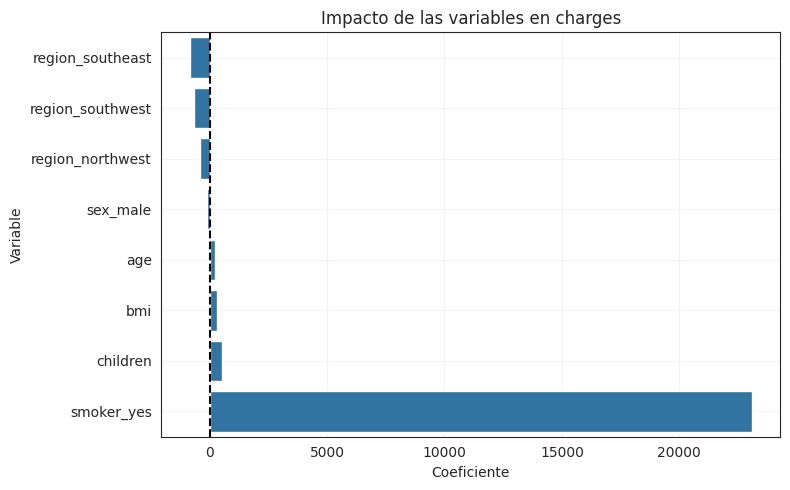

In [71]:
# Crear dataframe con los coeficientes del modelo
# Cada coeficiente indica el impacto de una variable en la predicción de charges
coef_df = pd.DataFrame({
    "variable": X_RLM.columns,
    "coeficiente": model.coef_
})

# Redondeamos para facilitar la lectura
coef_df["coeficiente"] = coef_df["coeficiente"].round(2)

# Ordenamos de menor a mayor para visualizar mejor positivos y negativos
coef_df_sorted = coef_df.sort_values(by="coeficiente")

plt.figure(figsize=(8,5))

# Gráfico de barras horizontal para ver el impacto de cada variable
sns.barplot(
    x="coeficiente",
    y="variable",
    data=coef_df_sorted
)

# Línea en 0 para separar efectos positivos y negativos
plt.axvline(0, color='black', linestyle='--')

plt.title("Impacto de las variables en charges")
plt.xlabel("Coeficiente")
plt.ylabel("Variable")

# Grid suave para mejorar la lectura
plt.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()


<div style="background-color: #fff3cd; border-left: 6px solid #ffecb5; padding: 15px; border-radius: 5px">

### **💡 Observación**

El gráfico de coeficientes permite visualizar el impacto de cada variable en la predicción de `charges`.

👉 Se observa claramente que `smoker_yes` es la variable con mayor influencia positiva, destacando muy por encima del resto.

👉 Variables como `age`, `bmi` y `children` tienen un impacto positivo moderado, mientras que algunas regiones presentan un efecto negativo.

👉 Esto refuerza lo observado en el EDA: el hábito de fumar es el factor más determinante en el coste del seguro.

</div>


In [72]:
# Realizamos predicciones sobre el conjunto de test
y_pred = model.predict(X_test)

In [73]:
# Calculamos métricas de evaluación del modelo
# MAE: error medio absoluto → promedio de los errores
mae = mean_absolute_error(y_test, y_pred)

# MSE: error cuadrático medio → penaliza más los errores grandes
mse = mean_squared_error(y_test, y_pred)

# RMSE: raíz del MSE → error en las mismas unidades que charges
rmse = np.sqrt(mse)

# R²: proporción de variabilidad explicada por el modelo
r2 = r2_score(y_test, y_pred)

# Guardamos métricas del modelo original para reutilizarlas más adelante
metrics_original = {
    "MAE": mae,
    "MSE": mse,
    "RMSE": rmse,
    "R2": r2
}

comparison_df = pd.DataFrame({
    "Modelo original": metrics_original})

comparison_df = comparison_df.map(lambda x: f"{x:.15f}")
comparison_df

,Modelo original
MAE,4171.800293113268708
MSE,35475294.142911337316036
RMSE,5956.114013592364245
R2,0.806943568034595



<div style="background-color: #fff3cd; border-left: 6px solid #ffecb5; padding: 15px; border-radius: 5px">

### **💡 Observación**

El modelo presenta un R² de aproximadamente 0.78, lo que indica que es capaz de explicar una parte significativa de la variabilidad de `charges`.

👉 El MAE (~4181) sugiere que, en promedio, las predicciones se desvían unos 4000 unidades del valor real.

👉 El RMSE (~5796), al penalizar más los errores grandes, indica la presencia de algunas predicciones con mayor desviación.

👉 En conjunto, el modelo ofrece un rendimiento razonable, aunque todavía existe margen de mejora.

</div>


<div style="background-color:#d6eaff; border-left:6px solid #4a90e2; padding:15px; border-radius:8px; color:#1b1b1b;">

### 📝 **Paso 4: Optimiza el modelo anterior**

Después de entrenar el modelo, si los resultados no son satisfactorios, optimízalo si fuera posible.

</div>


<div style="background-color: #fff3cd; border-left: 6px solid #ffecb5; padding: 15px; border-radius: 5px">

### **💡 Primera estrategia de optimización: eliminacion de una variable**

Como primer paso de optimización, se plantea una estrategia sencilla: 
eliminar variables con bajo impacto en el modelo.

A partir del análisis de coeficientes, se observa que la variable `sex` 
presenta un impacto prácticamente nulo sobre la variable objetivo `charges`.

👉 En este contexto, se decide eliminar `sex` del modelo para evaluar si:
- Se simplifica el modelo
- Se mantiene (o mejora) el rendimiento predictivo

👉 A continuación, se comparan las métricas del modelo original vs el modelo sin la variable `sex`.

</div>


In [74]:
# Eliminamos la variable sex de los datos de entrenamiento 

X_without_sex = X_RLM.drop("sex_male", axis=1)

In [75]:
# Creamos los 4 dataset de entrenamiento y test (sin sex en train y test)

X_train_wsex, X_test_wsex, y_train_new, y_test_new = train_test_split(X_without_sex, y_RLM, test_size=0.2, random_state=42)
X_train_wsex.shape, X_test_wsex.shape

((1069, 7), (268, 7))

In [76]:
# Entrenamos modelo de regresion: Pasandole los datos de entrenamiento sin la variable sex

model.fit(X_train_wsex, y_train_new)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [77]:
# Realizamos predicciones sobre el conjunto de test sin la variable sex
y_pred_new = model.predict(X_test_wsex)

In [78]:
# ===== EVALUAMOS MODELOS Y COMPARAMOS =====

# Métricas del modelo sin 'sex'
metrics_wsex = {
    "MAE": mean_absolute_error(y_test_new, y_pred_new),
    "MSE": mean_squared_error(y_test_new, y_pred_new),
    "RMSE": np.sqrt(mean_squared_error(y_test_new, y_pred_new)),
    "R2": r2_score(y_test_new, y_pred_new)
}

# DataFrame comparativo (puedes añadir más modelos aquí)
comparison_df = pd.DataFrame({
    "Modelo original": metrics_original,
    "Modelo sin sex": metrics_wsex,
})

# Formateamos sin notación científica y con todos los decimales
comparison_df = comparison_df.map(lambda x: f"{x:.15f}")

comparison_df

,Modelo original,Modelo sin sex
MAE,4171.800293113268708,4173.511833001268315
MSE,35475294.142911337316036,35489697.804688140749931
RMSE,5956.114013592364245,5957.323040148833570
R2,0.806943568034595,0.806865183355425


<div style="background-color: #fff3cd; border-left: 6px solid #ffecb5; padding: 15px; border-radius: 5px">

### 💡 **Resultado primera estrategia de optimización**

👉 Tras comparar las métricas del modelo original y el modelo sin `sex`, se observa que **no se producen cambios significativos**.

👉 Esto indica que la variable `sex` aporta muy poca información al modelo, o que su efecto ya está siendo capturado por otras variables.

👉 En consecuencia, eliminar variables de bajo impacto no siempre mejora el rendimiento, pero sí puede ayudar a simplificar el modelo sin perder capacidad predictiva.

</div>

<div style="background-color: #fff3cd; border-left: 6px solid #ffecb5; padding: 15px; border-radius: 5px">

### 💡 **Segunda estrategia de optimización: Escalado de variables**

Como siguiente paso, se plantea la posibilidad de escalar las variables numéricas.

👉 El objetivo del escalado sería:
- Poner todas las variables en la misma escala
- Evitar que variables con valores más grandes (como `charges` o `bmi`) dominen el modelo
- Mejorar potencialmente el rendimiento del modelo

👉 Sin embargo, al tratarse de un modelo de **regresión lineal**, creo que el escalado **no va a afectar el poder predictivo del modelo**, sino únicamente a la magnitud de los coeficientes.

👉 Además, el modelo actual ya muestra un buen rendimiento (R² ≈ 0.78), por lo que no vreo que sea un problema derivados de diferencias de escala.

👉 Sin embargo, se va a escalar para corroborar esta hipotesis de que no va a mejorar la predictibilidad del modelo.

</div>

In [79]:
# 1. Crear el scaler
# Este objeto se encargará de estandarizar las variables (media=0, desviación estándar=1)
scaler = StandardScaler()

# 2. Ajustar SOLO con los datos de entrenamiento (X_train) y transformarlos
# 👉 IMPORTANTE: aquí es donde el scaler "aprende"
X_train_scaled = scaler.fit_transform(X_train) 

# 3. Transformar los datos de test usando las MISMAS reglas aprendidas en train
X_test_scaled = scaler.transform(X_test) 



In [80]:
# Crear una nueva instancia del modelo de regresión lineal
model_scaled = LinearRegression()

In [81]:
# Entrenar el modelo usando los datos de entrenamiento ya escalados
model_scaled.fit(X_train_scaled, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [82]:
# Generar predicciones sobre el conjunto de test (también escalado)
y_pred_scaled = model_scaled.predict(X_test_scaled)

In [83]:
# Guardamos métricas del modelo escalado
metrics_scaled = {
    "MAE": mean_absolute_error(y_test, model_scaled.predict(X_test_scaled)),
    "MSE": mean_squared_error(y_test, model_scaled.predict(X_test_scaled)),
    "RMSE": np.sqrt(mean_squared_error(y_test, model_scaled.predict(X_test_scaled))),
    "R2": r2_score(y_test, model_scaled.predict(X_test_scaled))
}

# DataFrame comparativo
comparison_scaled_df = pd.DataFrame({
    "Modelo original": metrics_original,
    "Modelo escalado": metrics_scaled
})

# Formateamos sin notación científica y con todos los decimales
comparison_scaled_df = comparison_scaled_df.map(lambda x: f"{x:.15f}")

comparison_scaled_df

,Modelo original,Modelo escalado
MAE,4171.800293113268708,4171.800293113269618
MSE,35475294.142911337316036,35475294.142911277711391
RMSE,5956.114013592364245,5956.114013592358788
R2,0.806943568034595,0.806943568034595


<div style="background-color: #fff3cd; border-left: 6px solid #ffecb5; padding: 15px; border-radius: 5px">

### 💡 **Resultado segunda estrategia de optimización: Escalado de variables**

Al comparar el modelo original con el modelo escalado, se observa que las métricas son prácticamente idénticas.

👉 Esto confirma que **el escalado de variables no tiene impacto en el rendimiento de un modelo de regresión lineal**.

👉 Por tanto, el escalado no se considera una estrategia útil de optimización en este caso.

</div>

<div style="background-color: #fff3cd; border-left: 6px solid #ffecb5; padding: 15px; border-radius: 5px">

### 💡 **Tercera estrategia de optimización: Regularización con Lasso**

Volviendo a los coeficientes del modelo, se observa que varias variables presentan un impacto muy reducido sobre la variable objetivo `charges`.

👉 Esto puede indicar:
- Variables con poca capacidad explicativa
- Posible redundancia entre variables
- Un modelo más complejo de lo necesario

👉 En este contexto, se plantea utilizar **Lasso (L1 regularization)**, cuyo objetivo es:
- Penalizar coeficientes poco relevantes
- Reducir algunos coeficientes exactamente a 0
- Realizar una selección automática de variables

👉 Además, siguiendo el análisis previo de la variable `charges`, se incorpora una transformación logarítmica a `charges` para reducir su asimetría y facilitar el aprendizaje del modelo.

👉 A continuación, se entrena un modelo con Lasso y se comparan sus métricas con las del modelo original.

</div>

In [84]:

# Aplicamos log a `charges` para reducir su asimetría
y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

In [85]:
# Creamos el modelo Lasso con los siguientes hiperparámetros:
# alpha → intensidad de la penalización (mayor valor = más coeficientes a 0)
# max_iter → número máximo de iteraciones para asegurar la convergencia
lasso = Lasso(alpha=0.1, max_iter=10000)

# Entrenamos Lasso con variables escaladas y target en escala logarítmica
lasso.fit(X_train_scaled, y_train_log)



,"alpha alpha: float, default=1.0Constant that multiplies the L1 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Lasso` object is not advised.Instead, you should use the :class:`LinearRegression` object.",0.1
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.",False
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=1000The maximum number of iterations.",10000
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``, see Notes below.",0.0001
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fit asinitialization, otherwise, just erase the previous solution.See :term:`the Glossary `.",False
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.",False
,"random_state random_state: int, RandomState instance, default=NoneThe seed of the pseudo random number generator that selects a randomfeature to update. Used when ``selection`` == 'random'.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",None
,"selection selection: {'cyclic', 'random'}, default='cyclic'If set to 'random', a random coefficient is updated every iterationrather than looping over features sequentially by default. This(setting to 'random') often leads to significantly faster convergenceespecially when tol is higher than 1e-4.",'cyclic'


In [86]:
# Generamos predicciones en escala logarítmica
y_pred_log_lasso = lasso.predict(X_test_scaled)

# Convertimos las predicciones a la escala original de `charges`
# (revirtiendo la transformación logarítmica con expm1)
y_pred_lasso = np.expm1(y_pred_log_lasso)

In [87]:
# Métricas modelo Lasso (en escala real)
metrics_lasso = {
    "MAE": mean_absolute_error(y_test, y_pred_lasso),
    "MSE": mean_squared_error(y_test, y_pred_lasso),
    "RMSE": np.sqrt(mean_squared_error(y_test, y_pred_lasso)),
    "R2": r2_score(y_test, y_pred_lasso)
}

# DataFrame comparativo
comparison_df = pd.DataFrame({
    "Modelo original": metrics_original,
    "Lasso": metrics_lasso
})

# Formateo sin notación científica y con todos los decimales
comparison_df = comparison_df.map(lambda x: f"{x:.15f}")

comparison_df


,Modelo original,Lasso
MAE,4171.800293113268708,4302.022852607937239
MSE,35475294.142911337316036,61412085.846055440604687
RMSE,5956.114013592364245,7836.586364358874562
R2,0.806943568034595,0.665795634414446


<div style="background-color: #fff3cd; border-left: 6px solid #ffecb5; padding: 15px; border-radius: 5px">

### 💡 **Resultado tercera estrategia de optimización: Regularizacion con Lasso**

Al comparar el modelo Lasso con el modelo original, se observa un ligero empeoramiento en las métricas de evaluación.

👉 Esto indica que, aunque Lasso reduce la complejidad del modelo eliminando variables poco relevantes, también está descartando información que contribuye, aunque sea de forma marginal, a la predicción de `charges`.

👉 En este caso, las variables eliminadas no eran completamente irrelevantes, sino que aportaban valor en conjunto con otras variables.

👉 Como resultado, la simplificación del modelo provoca una pérdida de capacidad predictiva.

👉 Por tanto, Lasso no se considera una estrategia de optimización adecuada para este problema.


</div>

<div style="background-color: #fff3cd; border-left: 6px solid #ffecb5; padding: 15px; border-radius: 5px">

### 💡 **Cuarta estrategia de optimización: transformación logarítmica sobre variable objetivo**

A partir del análisis exploratorio, se observa que la variable objetivo `charges` presenta una distribución sesgada.

👉 Esto dificulta que un modelo de regresión lineal capture correctamente la relación con las variables independientes.

Para mejorar el rendimiento del modelo, se aplica una transformación logarítmica sobre `charges`, con el objetivo de:

- Reducir la asimetría
- Disminuir el impacto de valores extremos
- Aproximar relaciones más lineales

👉 A continuación, se entrena un modelo de regresión lineal utilizando la variable transformada (`log(charges)`).

Las predicciones se devuelven posteriormente a la escala original mediante la función inversa.

</div>

In [88]:
# Entrenamos modelo de regresión lineal con la variable objetivo en escala logarítmica
model_log = LinearRegression()
model_log.fit(X_train, y_train_log)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [89]:
# Generamos predicciones del modelo en escala logarítmica
y_pred_log_raw = model_log.predict(X_test)

# Revertimos la transformación logarítmica para volver a la escala original de `charges`
y_pred_log = np.expm1(y_pred_log_raw)

In [90]:
# Guardamos métricas del modelo con transformación logarítmica
metrics_log = {
    "MAE": mean_absolute_error(y_test, y_pred_log),
    "MSE": mean_squared_error(y_test, y_pred_log),
    "RMSE": np.sqrt(mean_squared_error(y_test, y_pred_log)),
    "R2": r2_score(y_test, y_pred_log)
}

# Creamos DataFrame comparativo
comparison_log_df = pd.DataFrame({
    "Modelo original": metrics_original,
    "Modelo con log": metrics_log
})

# Formateo sin notación científica y con todos los decimales
comparison_log_df = comparison_log_df.map(lambda x: f"{x:.15f}")

comparison_log_df

,Modelo original,Modelo con log
MAE,4171.800293113268708,3763.919179416086990
MSE,35475294.142911337316036,51920614.347875565290451
RMSE,5956.114013592364245,7205.596043900571203
R2,0.806943568034595,0.717448190533028


<div style="background-color: #fff3cd; border-left: 6px solid #ffecb5; padding: 15px; border-radius: 5px">

### 💡 **Resultado cuarta estrategia de optimización: transformación logarítmica sobre variable objetivo**

Al aplicar logaritmo a la variable objetivo `charges`, se observa que:

👉 El modelo NO mejora su capacidad de ajuste en la escala real (el R² disminuye).  
👉 Además, los errores (MSE y RMSE) aumentan.  

👉 Esto indica que, aunque la transformación logarítmica puede facilitar el aprendizaje interno del modelo, al volver a la escala original se pierde precisión.

👉 Conclusión:  
La transformación logarítmica no mejora el rendimiento del modelo en términos reales, por lo que se descarta como estrategia de optimización en este caso.

</div>

<div style="background-color: #fff3cd; border-left: 6px solid #ffecb5; padding: 15px; border-radius: 5px">

### 💡 **Quinta estrategia de optimización: Regularización Ridge**

Tras las estrategias anteriores, se observa que:

👉 Existen variables con bajo impacto en el modelo.  
👉 El modelo puede estar capturando ruido o pequeñas redundancias entre variables.  

👉 En este contexto, se plantea utilizar **Ridge (regularización L2)**, cuyo objetivo es:

- Reducir la magnitud de los coeficientes sin eliminarlos completamente  
- Mejorar la estabilidad del modelo  
- Evitar sobreajuste (overfitting)  

👉 A diferencia de Lasso, Ridge no elimina variables, sino que ajusta suavemente su influencia, lo que puede ser más adecuado en este caso.

👉 A continuación, se entrena un modelo Ridge y se comparan sus métricas con las del modelo original.

</div>

In [91]:
# ===== RIDGE =====

# Creamos el modelo Ridge con los siguientes hiperparámetros:
# alpha → intensidad de la penalización (más alto = coeficientes más pequeños)
ridge = Ridge(alpha=1.0)

# Entrenamos Ridge con variables escaladas y target en escala logarítmica
ridge.fit(X_train_scaled, y_train_log)



,"alpha alpha: {float, ndarray of shape (n_targets,)}, default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.",1.0
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard :func:`scipy.linalg.solve` function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in :func:`scipy.sparse.linalg.cg`. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine :func:`scipy.sparse.linalg.lsqr`. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its improved, unbiased version named SAGA. Both methods also use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`.- 'lbfgs' uses L-BFGS-B algorithm implemented in :func:`scipy.optimize.minimize`. It can be used only when `positive` is True.All solvers except 'svd' support both dense and sparse data. However, only'lsqr', 'sag', 'sparse_cg', and 'lbfgs' support sparse input when`fit_intercept` is True... versionadded:: 0.17 Stochastic Average Gradient descent solver... versionadded:: 0.19 SAGA solver.",'auto'
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.Only 'lbfgs' solver is supported in this case.",False
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag' or 'saga' to shuffle the data.See :term:`Glossary ` for details... versionadded:: 0.17 `random_state` to support Stochastic Average Gradient.",None


In [92]:
# Generamos predicciones en escala logarítmica
y_pred_log_ridge = ridge.predict(X_test_scaled)

# Convertimos las predicciones a la escala original de `charges`
# (revirtiendo la transformación logarítmica con expm1)
y_pred_ridge = np.expm1(y_pred_log_ridge)

In [93]:
# Métricas modelo Ridge (en escala real)
metrics_ridge = {
    "MAE": mean_absolute_error(y_test, y_pred_ridge),
    "MSE": mean_squared_error(y_test, y_pred_ridge),
    "RMSE": np.sqrt(mean_squared_error(y_test, y_pred_ridge)),
    "R2": r2_score(y_test, y_pred_ridge)
}

# Creamos DataFrame comparativo
comparison_ridge_df = pd.DataFrame({
    "Modelo original": metrics_original,
    "Ridge": metrics_ridge
})

# Formateo sin notación científica y con todos los decimales
comparison_ridge_df = comparison_ridge_df.map(lambda x: f"{x:.15f}")

comparison_ridge_df


,Modelo original,Ridge
MAE,4171.800293113268708,3762.293547701159241
MSE,35475294.142911337316036,51787401.504428707063198
RMSE,5956.114013592364245,7196.346399696773005
R2,0.806943568034595,0.718173134381111


<div style="background-color: #fff3cd; border-left: 6px solid #ffecb5; padding: 15px; border-radius: 5px">

### 💡 **Resultado de la quinta estrategia de optimización: Regularización Ridge**

Al aplicar regularización Ridge, se observa que el modelo no mejora su rendimiento respecto al modelo original.

Aunque la regularización ayuda a estabilizar los coeficientes y reducir posibles efectos de multicolinealidad, en este caso:

👉 El R² disminuye  
👉 Los errores (MSE y RMSE) aumentan  

Esto indica que el modelo original ya se encontraba bien ajustado y que la penalización introducida por Ridge está limitando su capacidad de ajuste.

👉 En este contexto, la regularización no aporta beneficios y se descarta como estrategia de optimización.

👉 Conclusión final:  
El modelo de regresión lineal original es el que mejor equilibrio ofrece entre ajuste y error en la escala real del problema.

</div>

In [94]:
# ===== COMPARACIÓN FINAL (TODOS EN ESCALA REAL) =====

comparison_final_df = pd.DataFrame({

    "Modelo original": {
        "MAE": mean_absolute_error(y_test, y_pred),
        "MSE": mean_squared_error(y_test, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, y_pred)),
        "R2": r2_score(y_test, y_pred)
    },

    "Modelo sin sex": {
        "MAE": mean_absolute_error(y_test_new, y_pred_new),
        "MSE": mean_squared_error(y_test_new, y_pred_new),
        "RMSE": np.sqrt(mean_squared_error(y_test_new, y_pred_new)),
        "R2": r2_score(y_test_new, y_pred_new)
    },

    "Modelo escalado": {
        "MAE": mean_absolute_error(y_test, model_scaled.predict(X_test_scaled)),
        "MSE": mean_squared_error(y_test, model_scaled.predict(X_test_scaled)),
        "RMSE": np.sqrt(mean_squared_error(y_test, model_scaled.predict(X_test_scaled))),
        "R2": r2_score(y_test, model_scaled.predict(X_test_scaled))
    },

    "Lasso (log + scaled)": {
        "MAE": mean_absolute_error(y_test, y_pred_lasso),
        "MSE": mean_squared_error(y_test, y_pred_lasso),
        "RMSE": np.sqrt(mean_squared_error(y_test, y_pred_lasso)),
        "R2": r2_score(y_test, y_pred_lasso)
    },

    "LinearReg (log)": {
        "MAE": mean_absolute_error(y_test, y_pred_log),
        "MSE": mean_squared_error(y_test, y_pred_log),
        "RMSE": np.sqrt(mean_squared_error(y_test, y_pred_log)),
        "R2": r2_score(y_test, y_pred_log)
    },

    "Ridge (log + scaled)": {
        "MAE": mean_absolute_error(y_test, y_pred_ridge),
        "MSE": mean_squared_error(y_test, y_pred_ridge),
        "RMSE": np.sqrt(mean_squared_error(y_test, y_pred_ridge)),
        "R2": r2_score(y_test, y_pred_ridge)
    }

})

# Formato bonito sin notación científica
comparison_final_df = comparison_final_df.map(lambda x: f"{x:.15f}")

comparison_final_df


,Modelo original,Modelo sin sex,Modelo escalado,Lasso (log + scaled),LinearReg (log),Ridge (log + scaled)
MAE,4171.800293113268708,4173.511833001268315,4171.800293113269618,4302.022852607937239,3763.919179416086990,3762.293547701159241
MSE,35475294.142911337316036,35489697.804688140749931,35475294.142911277711391,61412085.846055440604687,51920614.347875565290451,51787401.504428707063198
RMSE,5956.114013592364245,5957.323040148833570,5956.114013592358788,7836.586364358874562,7205.596043900571203,7196.346399696773005
R2,0.806943568034595,0.806865183355425,0.806943568034595,0.665795634414446,0.717448190533028,0.718173134381111


<div style="background-color:#d5f5e3; padding:20px; border-left:8px solid #27AE60; border-radius:8px; color:#1b1b1b;">

### 💡 **Conclusión final del modelo**

Tras evaluar distintas estrategias de optimización (eliminación de variables, escalado, transformación logarítmica y regularización), se concluye que el modelo de regresión lineal original ofrece el mejor rendimiento en la escala real del problema.

👉 Se consideró la eliminación de outliers en la variable objetivo `charges`, pero se descartó, ya que estos valores representan casos reales (altos costes médicos) y su eliminación implicaría perder información relevante.

👉 Asimismo, técnicas como la transformación logarítmica y la regularización no mejoraron el rendimiento global del modelo al evaluar en términos reales.

👉 Por tanto, se opta por mantener el modelo original por su mejor equilibrio entre capacidad predictiva e interpretabilidad.

</div>

<div style="background-color:#d6eaff; border-left:6px solid #4a90e2; padding:15px; border-radius:8px; color:#1b1b1b;">

### **Paso 5: Guardado del modelo**

</div>

In [24]:
# Guardar modelo
joblib.dump(model, "../models/linear_regression_medical_insurance_default.sav")

['../models/linear_regression_medical_insurance_default.sav']

<div style="background-color: #fff3cd; border-left: 6px solid #ffecb5; padding: 15px; border-radius: 5px">

### 💾 Guardado del modelo

Tras evaluar distintas alternativas de mejora, se conserva como versión final el modelo de regresión lineal base, ya que las pruebas realizadas no aportaron una mejora consistente en el rendimiento. Por ello, se procede a guardar esta versión final para su reutilización futura sin necesidad de repetir el entrenamiento.

</div>